# Problem: Generalization

***<span style="color:orange">Importing Libraries, Declaring Constants </span>***

In [1]:
import gzip
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

In [2]:
TRAIN_CORRELATION = 0.95
TEST_CORRELATION = 1.0
ERM_EPOCHS = 2
JTT_EPOCHS = 3
UPSAMPLING_RATE = 50
Q_VAL = 0.7

***<span style="color:purple">Load Images & Labels</span>***

In [3]:
def load_images(image_path):
    with gzip.open(image_path, 'rb') as f:
        data = f.read()
        images = np.frombuffer(data, dtype=np.uint8, offset=16)
        images = images.reshape(-1, 28, 28)
    return images

In [4]:
def load_labels(label_path):
    with gzip.open(label_path, 'rb') as f:
        data = f.read()
        labels = np.frombuffer(data, dtype=np.uint8, offset=8)
    return labels

In [5]:
train_images = load_images(r"Dataset\Mnist\train-images-idx3-ubyte.gz")
train_labels = load_labels(r"Dataset\Mnist\train-labels-idx1-ubyte.gz")
test_images = load_images(r"Dataset\Mnist\t10k-images-idx3-ubyte.gz")
test_labels = load_labels(r"Dataset\Mnist\t10k-labels-idx1-ubyte.gz")

In [6]:
print(train_images.shape, train_labels.shape)
print(test_images.shape, test_labels.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


***<span style="color:orange">Binary Classification</span>***

In [7]:
train_binary_labels = (train_labels >= 5).astype(np.int64)
test_binary_labels = (test_labels >= 5).astype(np.int64)

***<span style="color:purple">Colored MNIST</span>***


In [8]:
def colorize_train_MNIST(images, labels, correlation):
    N = images.shape[0]
    images = images / 255.0
    rgb = np.zeros((N, 28, 28, 3), dtype=np.float32)
    for i in range(N):
        if np.random.rand() < correlation:
            color = labels[i]      
        else:
            color = 1 - labels[i] 
        if color == 0:
            rgb[i, :, :, 0] = images[i] 
        else:
            rgb[i, :, :, 1] = images[i]  
    return rgb

In [9]:
def colorize_test_MNIST(images, labels, correlation):
    N = images.shape[0]
    images = images / 255.0
    rgb = np.zeros((N, 28, 28, 3), dtype=np.float32)
    for i in range(N):
        if np.random.rand() < correlation:
            color = 1 - labels[i] 
        else:
            color = labels[i]   
        if color == 0:
            rgb[i, :, :, 0] = images[i] 
        else:
            rgb[i, :, :, 1] = images[i]  
    return rgb

In [10]:
colored_train = colorize_train_MNIST(train_images, train_binary_labels, TRAIN_CORRELATION)
colored_test = colorize_test_MNIST(test_images, test_binary_labels, TEST_CORRELATION)

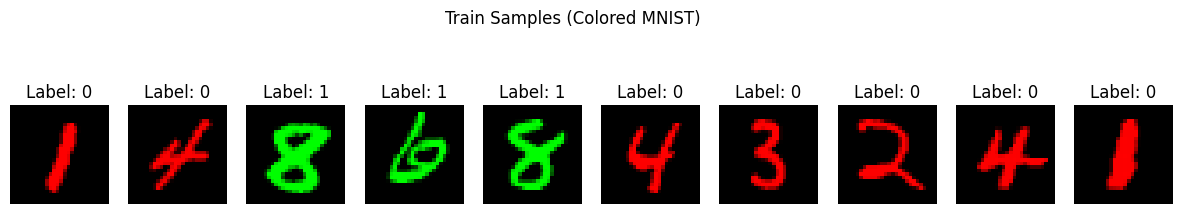

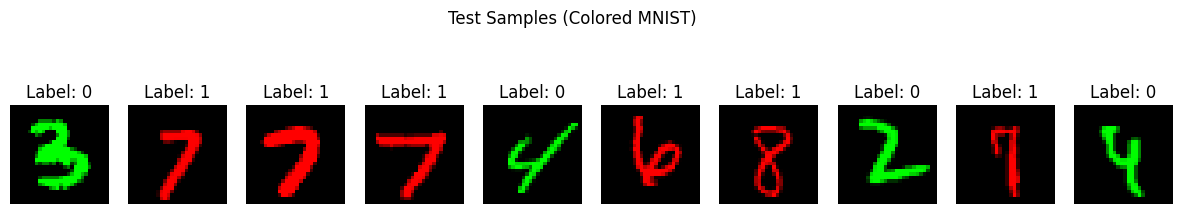

In [11]:
def visualize_samples(images, labels, title, n=10):
    idx = np.random.choice(len(images), n, replace=False)
    plt.figure(figsize=(15, 3))
    for i, j in enumerate(idx):
        plt.subplot(1, n, i+1)
        plt.imshow(images[j])
        plt.title(f"Label: {labels[j]}")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

visualize_samples(colored_train, train_binary_labels, "Train Samples (Colored MNIST)")
visualize_samples(colored_test, test_binary_labels, "Test Samples (Colored MNIST)")

***<span style="color:orange">Multi‑Layer Perceptron (MLP) Structure</span>***

In [12]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                     
            nn.Linear(2352, 128),            
            nn.ReLU(),
            nn.Linear(128, 2)                 
        )
    def forward(self, x):
        return self.net(x)

***<span style="color:purple">Load Data</span>***

In [13]:
X_train = torch.tensor(colored_train, dtype=torch.float32)
y_train = torch.tensor(train_binary_labels, dtype=torch.long)
X_test = torch.tensor(colored_test, dtype=torch.float32)
y_test = torch.tensor(test_binary_labels, dtype=torch.long)

In [14]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=128, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test,  y_test), batch_size=128, shuffle=False)

***<span style="color:Orange">ERM Training Loop</span>***

In [15]:
model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(ERM_EPOCHS):
    model.train()
    for X, y in train_loader:
        optimizer.zero_grad()
        model_out = model(X)
        loss = criterion(model_out, y)
        loss.backward()
        optimizer.step()
        
    print(f"Epoch {epoch+1}/{ERM_EPOCHS} - Loss: {loss.item():.4f}")

Epoch 1/2 - Loss: 0.0717
Epoch 2/2 - Loss: 0.0657


***<span style="color:purple">Accuracy</span>***

In [16]:
def accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in loader:
            model_out = model(X)
            preds = torch.argmax(model_out, dim=1) 
            y = y.squeeze()
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

In [17]:
def worst_group_loss(model, loader, group_labels):
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction="none")
    group_losses = {}
    group_counts = {}
    index = 0
    with torch.no_grad():
        for X, y in loader:
            batch_size = X.size(0)
            model_output = model(X)
            losses = criterion(model_output, y)
            groups = group_labels[index:index+batch_size]
            index += batch_size
            for group, loss in zip(groups, losses):
                group = int(group)
                group_losses[group] = group_losses.get(group, 0) + loss.item()
                group_counts[group] = group_counts.get(group, 0) + 1
    avg_group_losses = {group: group_losses[group] / group_counts[group] for group in group_losses}
    worst_loss = max(avg_group_losses.values())
    return worst_loss, avg_group_losses


In [32]:
test_groups = y_test.numpy() 

worst_loss, group_losses = worst_group_loss(model, test_loader, test_groups)

for group, loss in group_losses.items():
    print(f"Group {group}: {loss:.4f}")
print(f"Worst group loss: {worst_loss:.4f}")

Group 1: 0.9612
Group 0: 0.9239
Worst group loss: 0.9612


In [19]:
train_accuracy = accuracy(model, train_loader)
test_accuracy = accuracy(model, test_loader)

print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Difference: {train_accuracy - test_accuracy:.4f}")

Train accuracy: 0.9797
Test accuracy: 0.6271
Difference: 0.3526


***<span style="color:Orange">Extract Error Set</span>***

In [20]:
def get_error_set(model, loader):
    model.eval()
    error_indices = []
    with torch.no_grad():
        sample_index = 0  
        for X, y in loader:
            model_out = model(X)
            preds = torch.argmax(model_out, dim=1)
            y = y.squeeze()
            wrong_mask = (preds != y)
            batch_error_indices = torch.where(wrong_mask)[0].tolist()
            batch_error_indices = [sample_index + batch_error for batch_error in batch_error_indices]
            error_indices.extend(batch_error_indices)
            sample_index += y.size(0)
    return error_indices

In [21]:
error_set = get_error_set(model, train_loader)
print("Number of misclassified samples: ", len(error_set))

Number of misclassified samples:  1217


***<span style="color:purple">Upsampling</span>***

In [22]:
upsampled_indices = list(range(len(X_train)))

for index in error_set:
    upsampled_indices.extend([index] * UPSAMPLING_RATE)

X_upsampled_train = X_train[upsampled_indices]
y_upsampled_train = y_train[upsampled_indices]

upsampled_dataset = torch.utils.data.TensorDataset(X_upsampled_train, y_upsampled_train)

print("Total number of samples in the new upsampled dataset:", len(upsampled_dataset))

Total number of samples in the new upsampled dataset: 120850


***<span style="color:Orange">Re-training the Model</span>***

In [23]:
jtt_model = MLP()

upsampled_train_loader = DataLoader(upsampled_dataset, batch_size=128, shuffle=True)
jtt_optimizer = optim.Adam(jtt_model.parameters(), lr=1e-3)

for epoch in range(JTT_EPOCHS):
    jtt_model.train()
    for X, y in upsampled_train_loader:
        jtt_optimizer.zero_grad()
        model_out = jtt_model(X)
        loss = criterion(model_out, y)
        loss.backward()
        jtt_optimizer.step()
    print(f"Epoch {epoch+1}/{JTT_EPOCHS} - Loss: {loss.item():.4f}")

Epoch 1/3 - Loss: 0.0070
Epoch 2/3 - Loss: 0.0220
Epoch 3/3 - Loss: 0.0049


In [36]:
jtt_worst_loss, jtt_group_losses = worst_group_loss(jtt_model, test_loader, test_groups)

for group, loss in jtt_group_losses.items():
    print(f"Group {group}: {loss:.4f}")
print(f"JTT worst group loss:{jtt_worst_loss:.4f}")

Group 1: 0.6598
Group 0: 0.6564
JTT worst group loss:0.6598


In [25]:
jtt_train_accuracy = accuracy(jtt_model, train_loader)
jtt_test_accuracy = accuracy(jtt_model, test_loader)
print(f"Train accuracy: {jtt_train_accuracy:.4f}")
print(f"Test accuracy: {jtt_test_accuracy:.4f}")
print(f"Difference: {jtt_train_accuracy - jtt_test_accuracy:.4f}")

Train accuracy: 0.9891
Test accuracy: 0.7897
Difference: 0.1994


***<span style="color:Purple">GCE Loss Function</span>***

In [26]:
class GCELoss(nn.Module):
    def __init__(self, q):
        super(GCELoss, self).__init__()
        self.q = q
    def forward(self, logits, targets):
        batch_size = logits.size(0)
        log_probs = F.log_softmax(logits, dim=1)
        probs_with_correct_class = torch.exp(log_probs[torch.arange(batch_size), targets])
        if abs(self.q) < 1e-8:
            loss = -torch.log(probs_with_correct_class)      
        else:
            loss = (1 - probs_with_correct_class.pow(self.q)) / self.q 
        return loss.mean()

In [27]:
gce_model = MLP()
gce_criterion = GCELoss(q = Q_VAL)
gce_optimizer = optim.Adam(gce_model.parameters(), lr=1e-3)

for epoch in range(ERM_EPOCHS):
    gce_model.train()
    total_loss = 0
    for X, y in train_loader:
        gce_optimizer.zero_grad()
        model_out = gce_model(X)
        loss = gce_criterion(model_out, y)
        loss.backward()
        gce_optimizer.step()

    print(f"Epoch {epoch+1}/{ERM_EPOCHS} - Loss: {loss.item():.4f}")


Epoch 1/2 - Loss: 0.0451
Epoch 2/2 - Loss: 0.0409


In [28]:
error_set_gce = get_error_set(gce_model, train_loader)
print(f"Number of misclassified samples with GCE: {len(error_set_gce)}")

Number of misclassified samples with GCE: 2344


In [37]:
gce_worst_loss, gce_group_losses = worst_group_loss(gce_model, test_loader, test_groups)

for group, loss in gce_group_losses.items():
    print(f"Group {group}: {loss:.4f}")
print(f"GCE worst group loss: {gce_worst_loss:.4f}")

Group 1: 9.5267
Group 0: 12.5821
GCE worst group loss: 12.5821


In [30]:
gce_train_accuracy = accuracy(gce_model, train_loader)
gce_test_accuracy = accuracy(gce_model, test_loader)
print(f"Train accuracy: {gce_train_accuracy:.4f}")
print(f"Test accuracy: {gce_test_accuracy:.4f}")
print(f"Difference: {gce_train_accuracy - gce_test_accuracy:.4f}")

Train accuracy: 0.9609
Test accuracy: 0.2885
Difference: 0.6724
